#  Decision Delay Cost Analyzer – Supply Chain Analytics

##  Objective
This project analyzes delays in supply chain operations using IoT and logistics data.

We aim to:
- Identify factors causing delivery delays
- Analyze impact of traffic, weather, and port congestion
- Study fuel, inventory, and route risk effects
- Understand delay probability and cost impact
- Generate business insights for logistics optimization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##  Load Dataset

We load the logistics dataset containing:
- Vehicle tracking data
- Environmental conditions
- Operational factors
- Delay and risk indicators

In [2]:
df = pd.read_csv("C:/Users/surek/OneDrive/Desktop/dynamic_supply_chain_logistics_dataset.csv")
df.head()

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,-6.491034,0.253529,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484


##  Dataset Overview

We inspect dataset structure, datatypes, and missing values to understand data quality.

In [6]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32065 entries, 0 to 32064
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   timestamp                        32065 non-null  object 
 1   vehicle_gps_latitude             32065 non-null  float64
 2   vehicle_gps_longitude            32065 non-null  float64
 3   fuel_consumption_rate            32065 non-null  float64
 4   eta_variation_hours              32065 non-null  float64
 5   traffic_congestion_level         32065 non-null  float64
 6   warehouse_inventory_level        32065 non-null  float64
 7   loading_unloading_time           32065 non-null  float64
 8   handling_equipment_availability  32065 non-null  float64
 9   order_fulfillment_status         32065 non-null  float64
 10  weather_condition_severity       32065 non-null  float64
 11  port_congestion_level            32065 non-null  float64
 12  shipping_costs    

Index(['timestamp', 'vehicle_gps_latitude', 'vehicle_gps_longitude',
       'fuel_consumption_rate', 'eta_variation_hours',
       'traffic_congestion_level', 'warehouse_inventory_level',
       'loading_unloading_time', 'handling_equipment_availability',
       'order_fulfillment_status', 'weather_condition_severity',
       'port_congestion_level', 'shipping_costs', 'supplier_reliability_score',
       'lead_time_days', 'historical_demand', 'iot_temperature',
       'cargo_condition_status', 'route_risk_level', 'customs_clearance_time',
       'driver_behavior_score', 'fatigue_monitoring_score',
       'disruption_likelihood_score', 'delay_probability',
       'risk_classification', 'delivery_time_deviation'],
      dtype='object')

##  Timestamp Processing

We convert timestamp column into datetime format for time-based analysis.

In [7]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [8]:
df.isnull().sum()

timestamp                          0
vehicle_gps_latitude               0
vehicle_gps_longitude              0
fuel_consumption_rate              0
eta_variation_hours                0
traffic_congestion_level           0
warehouse_inventory_level          0
loading_unloading_time             0
handling_equipment_availability    0
order_fulfillment_status           0
weather_condition_severity         0
port_congestion_level              0
shipping_costs                     0
supplier_reliability_score         0
lead_time_days                     0
historical_demand                  0
iot_temperature                    0
cargo_condition_status             0
route_risk_level                   0
customs_clearance_time             0
driver_behavior_score              0
fatigue_monitoring_score           0
disruption_likelihood_score        0
delay_probability                  0
risk_classification                0
delivery_time_deviation            0
dtype: int64

##  Feature Understanding

Key variables in this dataset:

-  Vehicle movement: GPS, fuel consumption
-  Environment: weather, traffic, port congestion
-  Operations: inventory, loading time, customs delay
-  Risk: route risk, disruption likelihood
-  Target: delivery_time_deviation, delay_probability

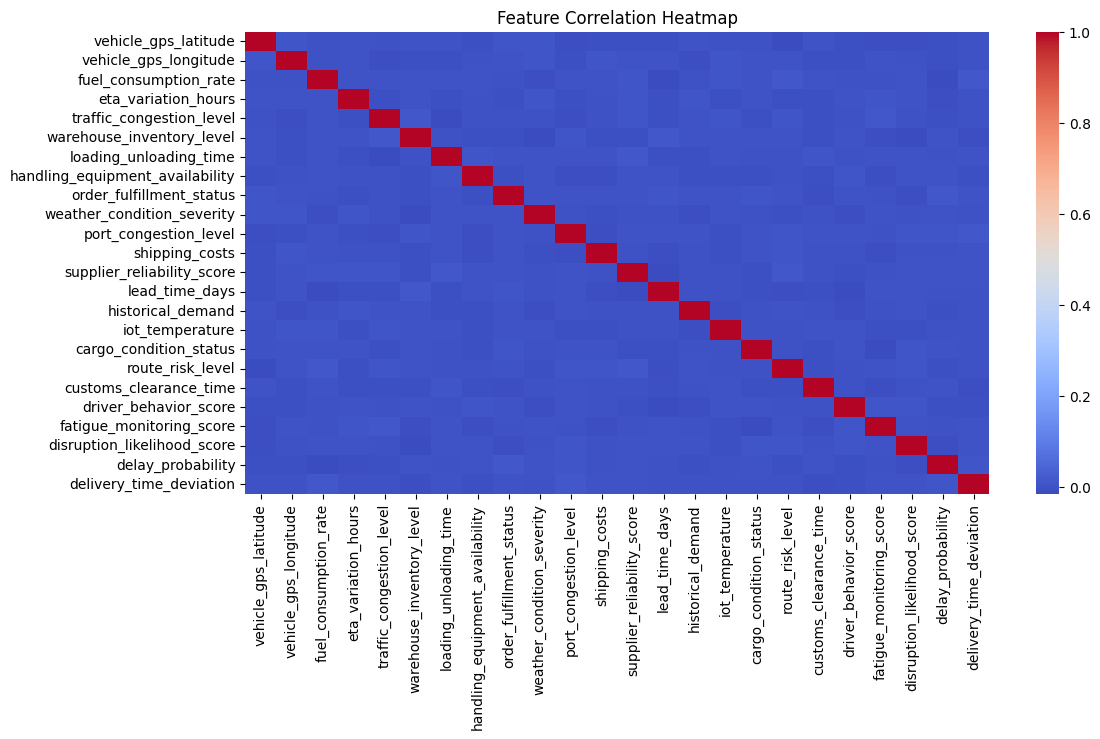

In [9]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

##  Delay Analysis

We analyze how different factors affect delivery time deviation.

In [10]:
delay_corr = df.corr(numeric_only=True)['delivery_time_deviation'].sort_values(ascending=False)
delay_corr

delivery_time_deviation            1.000000
fuel_consumption_rate              0.012495
port_congestion_level              0.010612
delay_probability                  0.005530
supplier_reliability_score         0.004384
fatigue_monitoring_score           0.003491
loading_unloading_time             0.003375
order_fulfillment_status           0.003329
disruption_likelihood_score        0.002622
shipping_costs                     0.002504
historical_demand                  0.000615
traffic_congestion_level           0.000510
vehicle_gps_latitude               0.000416
route_risk_level                  -0.000076
weather_condition_severity        -0.000541
iot_temperature                   -0.000569
eta_variation_hours               -0.000746
cargo_condition_status            -0.001348
vehicle_gps_longitude             -0.001639
lead_time_days                    -0.002460
driver_behavior_score             -0.003969
handling_equipment_availability   -0.004639
warehouse_inventory_level       

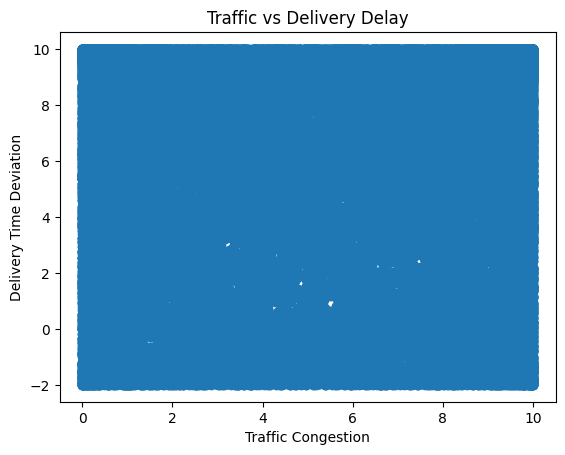

In [11]:
plt.scatter(df['traffic_congestion_level'], df['delivery_time_deviation'])
plt.title("Traffic vs Delivery Delay")
plt.xlabel("Traffic Congestion")
plt.ylabel("Delivery Time Deviation")
plt.show()

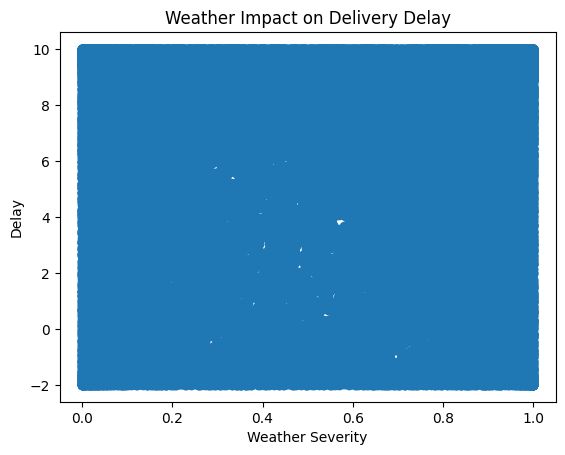

In [12]:
plt.scatter(df['weather_condition_severity'], df['delivery_time_deviation'])
plt.title("Weather Impact on Delivery Delay")
plt.xlabel("Weather Severity")
plt.ylabel("Delay")
plt.show()

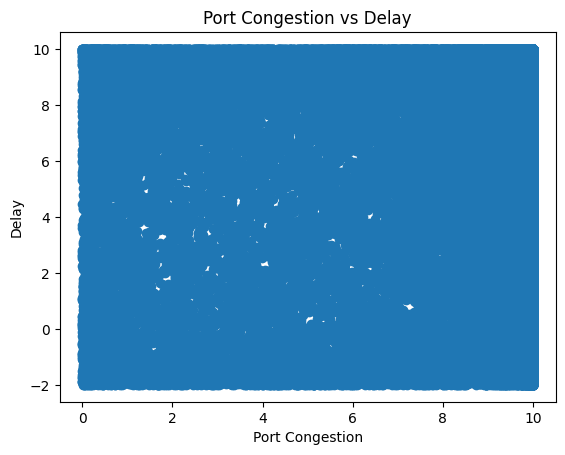

In [13]:
plt.scatter(df['port_congestion_level'], df['delivery_time_deviation'])
plt.title("Port Congestion vs Delay")
plt.xlabel("Port Congestion")
plt.ylabel("Delay")
plt.show()

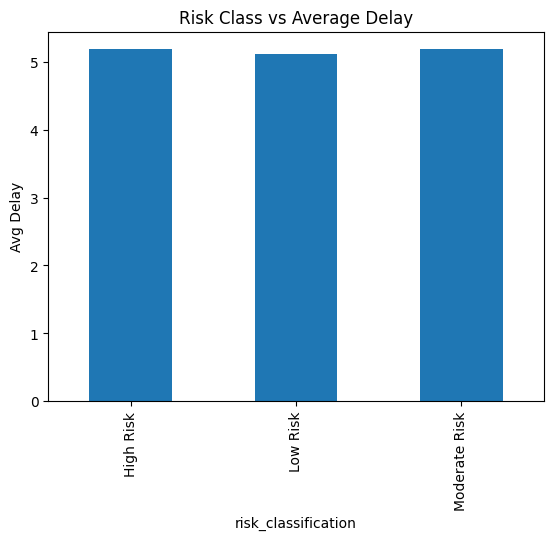

In [14]:
df.groupby("risk_classification")["delivery_time_deviation"].mean().plot(kind="bar")
plt.title("Risk Class vs Average Delay")
plt.ylabel("Avg Delay")
plt.show()

##  Delay Probability Analysis

We analyze how operational factors influence probability of delay.

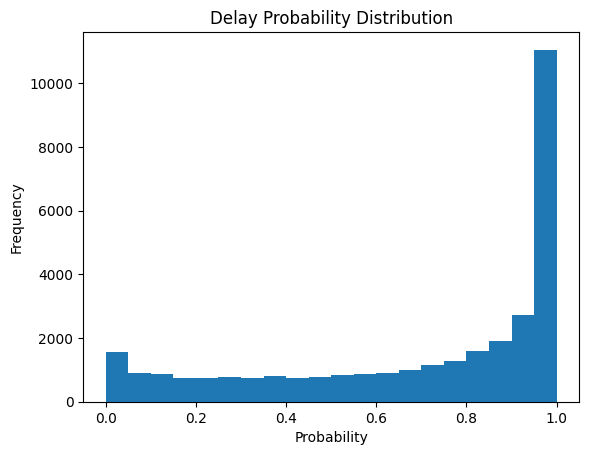

In [15]:
plt.hist(df['delay_probability'], bins=20)
plt.title("Delay Probability Distribution")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

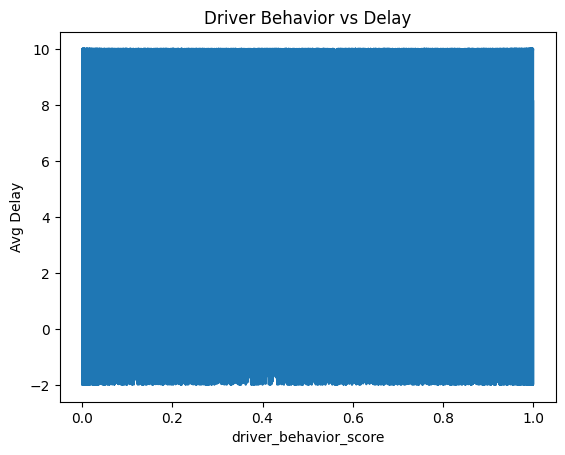

In [17]:
df.groupby("driver_behavior_score")["delivery_time_deviation"].mean().plot(kind="line")
plt.title("Driver Behavior vs Delay")
plt.ylabel("Avg Delay")
plt.show()

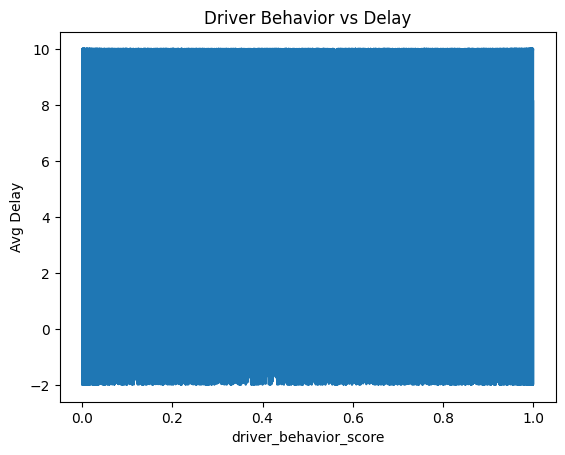

In [18]:
df.groupby("driver_behavior_score")["delivery_time_deviation"].mean().plot(kind="line")
plt.title("Driver Behavior vs Delay")
plt.ylabel("Avg Delay")
plt.show()

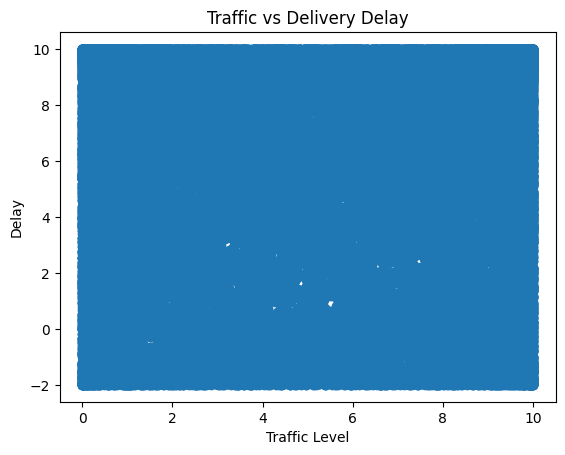

In [20]:
plt.scatter(df['traffic_congestion_level'], df['delivery_time_deviation'])
plt.title("Traffic vs Delivery Delay")
plt.xlabel("Traffic Level")
plt.ylabel("Delay")
plt.show()

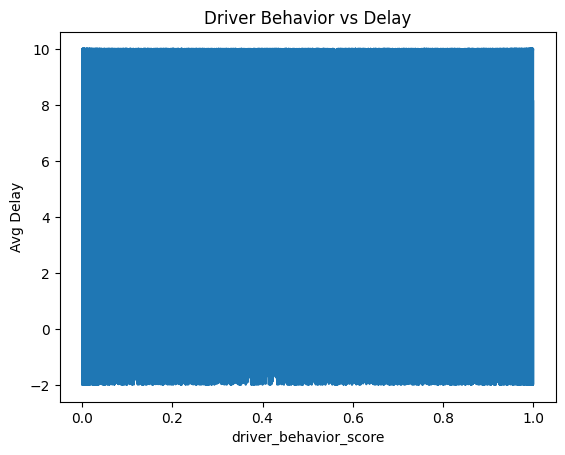

In [23]:
df.groupby("driver_behavior_score")["delivery_time_deviation"].mean().plot()
plt.title("Driver Behavior vs Delay")
plt.ylabel("Avg Delay")
plt.show()

##  Business KPIs

We calculate key operational KPIs:
- Average delivery delay
- High-risk route percentage
- Worst performing factors

In [24]:
print("Average Delay:", df['delivery_time_deviation'].mean())

print("Max Delay:", df['delivery_time_deviation'].max())

print("Min Delay:", df['delivery_time_deviation'].min())

Average Delay: 5.177648068922158
Max Delay: 9.99999999998948
Min Delay: -1.9999979891152304


In [25]:
high_risk = df[df['disruption_likelihood_score'] > df['disruption_likelihood_score'].mean()]
high_risk.shape

(21957, 26)

##  Advanced Data Analysis Phase

In this section, we go deeper into:
- Identifying strongest delay drivers
- Segment-wise performance analysis
- Operational bottlenecks
- Risk-based grouping insights

This helps convert raw data into business decisions.

In [26]:
corr = df.corr(numeric_only=True)['delivery_time_deviation'].sort_values(ascending=False)
corr

delivery_time_deviation            1.000000
fuel_consumption_rate              0.012495
port_congestion_level              0.010612
delay_probability                  0.005530
supplier_reliability_score         0.004384
fatigue_monitoring_score           0.003491
loading_unloading_time             0.003375
order_fulfillment_status           0.003329
disruption_likelihood_score        0.002622
shipping_costs                     0.002504
historical_demand                  0.000615
traffic_congestion_level           0.000510
vehicle_gps_latitude               0.000416
route_risk_level                  -0.000076
weather_condition_severity        -0.000541
iot_temperature                   -0.000569
eta_variation_hours               -0.000746
cargo_condition_status            -0.001348
vehicle_gps_longitude             -0.001639
lead_time_days                    -0.002460
driver_behavior_score             -0.003969
handling_equipment_availability   -0.004639
warehouse_inventory_level       

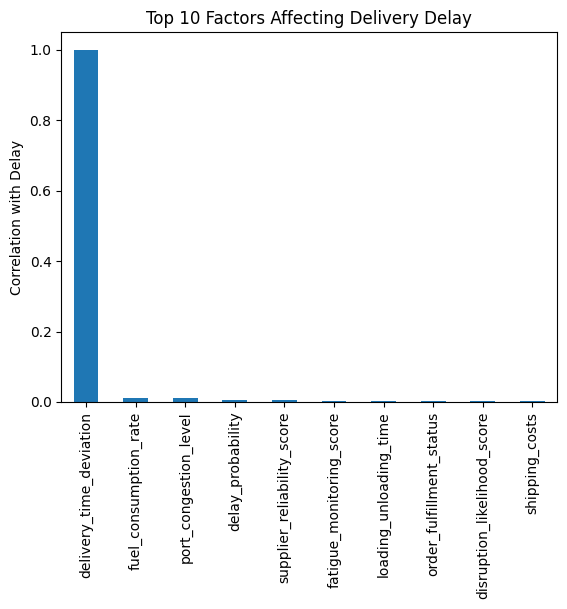

In [27]:
top_features = corr.head(10)

top_features.plot(kind='bar')
plt.title("Top 10 Factors Affecting Delivery Delay")
plt.ylabel("Correlation with Delay")
plt.show()

In [28]:
corr.tail(10)

weather_condition_severity        -0.000541
iot_temperature                   -0.000569
eta_variation_hours               -0.000746
cargo_condition_status            -0.001348
vehicle_gps_longitude             -0.001639
lead_time_days                    -0.002460
driver_behavior_score             -0.003969
handling_equipment_availability   -0.004639
warehouse_inventory_level         -0.007463
customs_clearance_time            -0.009244
Name: delivery_time_deviation, dtype: float64

##  Delay Distribution Analysis

We check how delivery delays are distributed:
- Normal vs skewed patterns
- Presence of extreme delays
- Operational instability

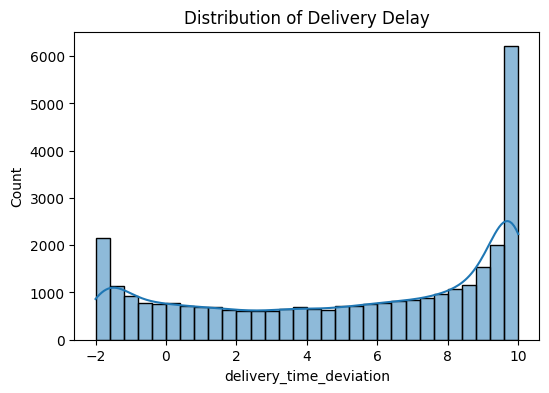

In [29]:
plt.figure(figsize=(6,4))
sns.histplot(df['delivery_time_deviation'], bins=30, kde=True)
plt.title("Distribution of Delivery Delay")
plt.show()

In [30]:
Q1 = df['delivery_time_deviation'].quantile(0.25)
Q3 = df['delivery_time_deviation'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df['delivery_time_deviation'] < (Q1 - 1.5 * IQR)) |
    (df['delivery_time_deviation'] > (Q3 + 1.5 * IQR))
]

outliers.shape

(0, 26)

In [31]:
high_delay = df[df['delivery_time_deviation'] > df['delivery_time_deviation'].mean()]
high_delay.head()

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484
7,2021-01-01 07:00:00,32.601885,-102.316635,5.474695,0.375511,4.813078,256.293208,2.352963,0.021812,0.240859,...,36.838728,0.344496,2.954216,1.456898,0.012490,0.185078,0.514001,0.979538,Moderate Risk,7.432758


##  Traffic Impact Analysis

We group data to understand how traffic congestion impacts delays.

In [32]:
df.groupby("traffic_congestion_level")["delivery_time_deviation"].mean()

traffic_congestion_level
1.091633e-09   -1.348396
7.506831e-09    9.990905
3.711446e-08    8.446229
3.811039e-08    9.985208
6.842729e-08    9.906461
                  ...   
9.999998e+00    2.192613
9.999998e+00    5.199888
9.999999e+00    9.969584
9.999999e+00    5.247133
9.999999e+00    4.825702
Name: delivery_time_deviation, Length: 32065, dtype: float64

In [33]:
df.groupby("weather_condition_severity")["delivery_time_deviation"].mean()

weather_condition_severity
4.536949e-09    9.533920
9.145892e-09    7.761452
1.256987e-08    5.003781
1.380562e-08    9.126022
7.347305e-08    0.014250
                  ...   
9.999999e-01    9.732892
9.999999e-01    3.164777
1.000000e+00    7.451397
1.000000e+00    8.025890
1.000000e+00    0.085962
Name: delivery_time_deviation, Length: 32065, dtype: float64

In [34]:
df.groupby("port_congestion_level")["delivery_time_deviation"].mean()

port_congestion_level
0.000002    -1.507808
0.000007     7.347861
0.000008    -0.247401
0.000029    -1.070495
0.000053     7.912456
               ...   
10.000000   -1.580639
10.000000    2.835711
10.000000    9.238441
10.000000    0.966603
10.000000    8.865865
Name: delivery_time_deviation, Length: 32065, dtype: float64

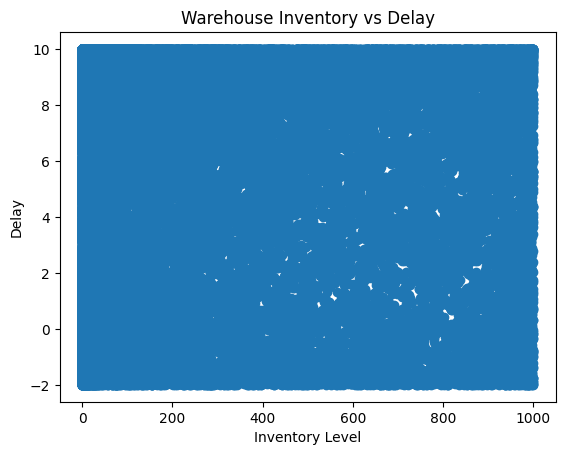

In [35]:
plt.scatter(df['warehouse_inventory_level'], df['delivery_time_deviation'])
plt.title("Warehouse Inventory vs Delay")
plt.xlabel("Inventory Level")
plt.ylabel("Delay")
plt.show()

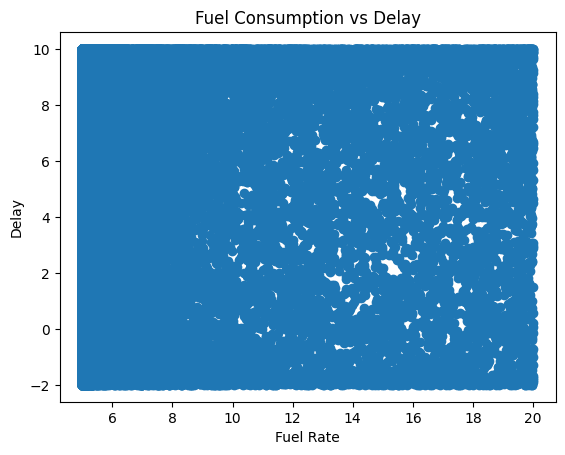

In [36]:
plt.scatter(df['fuel_consumption_rate'], df['delivery_time_deviation'])
plt.title("Fuel Consumption vs Delay")
plt.xlabel("Fuel Rate")
plt.ylabel("Delay")
plt.show()

##  Risk Segmentation Analysis

We analyze how disruption likelihood score impacts delivery delay.

In [38]:
df.groupby("disruption_likelihood_score")["delivery_time_deviation"].mean()

disruption_likelihood_score
0.000048    2.005974
0.000117    3.671836
0.000184    4.953349
0.000202   -1.387897
0.000218    4.784677
              ...   
1.000000   -0.505013
1.000000    6.834815
1.000000    8.226936
1.000000    7.858534
1.000000    4.544541
Name: delivery_time_deviation, Length: 32030, dtype: float64

In [39]:
high_risk = df[df['disruption_likelihood_score'] > df['disruption_likelihood_score'].median()]
low_risk = df[df['disruption_likelihood_score'] <= df['disruption_likelihood_score'].median()]

print("High Risk Avg Delay:", high_risk['delivery_time_deviation'].mean())
print("Low Risk Avg Delay:", low_risk['delivery_time_deviation'].mean())

High Risk Avg Delay: 5.198025000208362
Low Risk Avg Delay: 5.157272408572853


In [40]:
df['efficiency_score'] = (
    df['driver_behavior_score'] +
    df['handling_equipment_availability'] -
    df['traffic_congestion_level'] -
    df['weather_condition_severity']
)

df[['efficiency_score', 'delivery_time_deviation']].corr()

,efficiency_score,delivery_time_deviation
efficiency_score,1.000000,-0.001264
delivery_time_deviation,-0.001264,1.000000


#  KPI Dashboard Summary

This section summarizes key business metrics:
- Average delivery delay
- Total high-risk shipments
- Most impactful delay factor
- Operational efficiency indicators

These KPIs help management make data-driven decisions.

In [41]:
avg_delay = df['delivery_time_deviation'].mean()
max_delay = df['delivery_time_deviation'].max()
min_delay = df['delivery_time_deviation'].min()

high_risk_count = df[df['disruption_likelihood_score'] > df['disruption_likelihood_score'].median()].shape[0]

print(" Average Delay:", avg_delay)
print(" Max Delay:", max_delay)
print(" Min Delay:", min_delay)
print(" High Risk Shipments:", high_risk_count)

 Average Delay: 5.177648068922158
 Max Delay: 9.99999999998948
 Min Delay: -1.9999979891152304
 High Risk Shipments: 16032


## Delay Severity Classification

We categorize deliveries into:
- Low Delay
- Medium Delay
- High Delay
based on distribution of delay values.

In [42]:
df['delay_category'] = pd.cut(
    df['delivery_time_deviation'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

df['delay_category'].value_counts()

delay_category
High      16244
Low        9224
Medium     6597
Name: count, dtype: int64

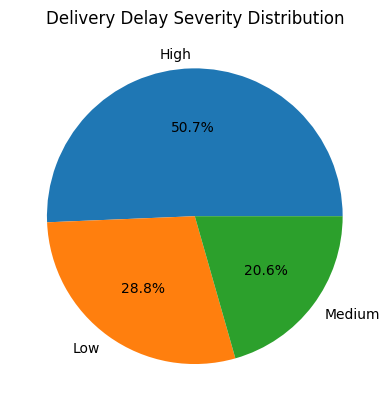

In [43]:
df['delay_category'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Delivery Delay Severity Distribution")
plt.ylabel("")
plt.show()

##  Business Impact Ranking

We rank factors contributing most to delivery delays.

In [44]:
impact_scores = df.corr(numeric_only=True)['delivery_time_deviation'].abs().sort_values(ascending=False)

impact_scores

delivery_time_deviation            1.000000
fuel_consumption_rate              0.012495
port_congestion_level              0.010612
customs_clearance_time             0.009244
warehouse_inventory_level          0.007463
delay_probability                  0.005530
handling_equipment_availability    0.004639
supplier_reliability_score         0.004384
driver_behavior_score              0.003969
fatigue_monitoring_score           0.003491
loading_unloading_time             0.003375
order_fulfillment_status           0.003329
disruption_likelihood_score        0.002622
shipping_costs                     0.002504
lead_time_days                     0.002460
vehicle_gps_longitude              0.001639
cargo_condition_status             0.001348
efficiency_score                   0.001264
eta_variation_hours                0.000746
historical_demand                  0.000615
iot_temperature                    0.000569
weather_condition_severity         0.000541
traffic_congestion_level        

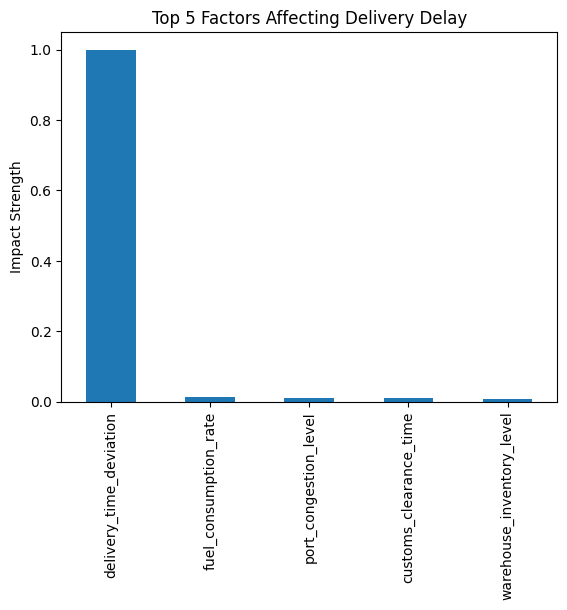

In [45]:
impact_scores.head(5).plot(kind='bar')
plt.title("Top 5 Factors Affecting Delivery Delay")
plt.ylabel("Impact Strength")
plt.show()

##  Operational Efficiency Insight

We analyze how operational parameters affect delivery performance:
- Driver behavior
- Handling efficiency
- Inventory availability
- Equipment availability

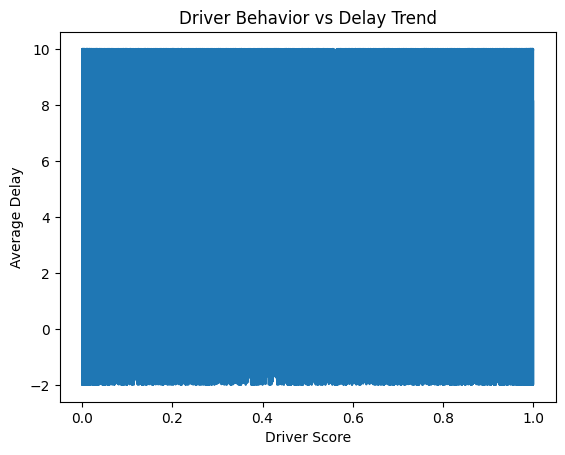

In [46]:
df.groupby("driver_behavior_score")["delivery_time_deviation"].mean().plot()
plt.title("Driver Behavior vs Delay Trend")
plt.xlabel("Driver Score")
plt.ylabel("Average Delay")
plt.show()